# MNIST CNN Model Training, Evaluation, and Weight Export

## 0. Install Dependencies

Note: Python version 3.11.7 is used in this notebook.

In [1]:
%pip install numpy tensorflow matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


## 1. Import Required Libraries

In [1]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random
import csv

from sklearn.model_selection import train_test_split

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

## 2. Load and Preprocess the MNIST Dataset
Load the MNIST dataset and preprocess it by normalizing the images and one-hot encoding the labels.

In [4]:
# Load and preprocess MNIST dataset
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0  # Normalize the images to [0, 1]
x_train = np.expand_dims(x_train, -1)  # Add channel dimension
y_train = tf.keras.utils.to_categorical(y_train, 10)  # One-hot encode the labels

### 2.2 Prepare the test and train datasets

In [5]:
# Split the dataset into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

### 2.3 Save some images for later use in C/RiscV programs

In [6]:
indices = random.sample(range(x_train.shape[0]), 100)

with open("mnist_samples.csv", "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    
    for idx in indices:
        image = x_train[idx].squeeze()  # (28, 28)
        label = np.argmax(y_train[idx])  # Get label
        
        # Flatten the image and combine it with the label
        row = [label] + image.flatten().tolist()
        
        # Write row to CSV
        writer.writerow(row)


## 3. Visualize MNIST Images


### 3.1 Define a function to display images

In [7]:
def plot_mnist_images(x_data, num_images=25):
    """
    Function to plot a grid of random MNIST images from the dataset.
    
    Parameters:
    x_data (numpy array): The input images (28x28 grayscale).
    num_images (int): Number of images to display.
    """
    # Randomly select num_images indices from the dataset
    random_indices = np.random.choice(len(x_data), num_images, replace=False)

    # Get the corresponding images using the random indices
    random_images = x_data[random_indices]

    # Calculate the number of rows and columns needed to display the images
    cols = int(np.ceil(np.sqrt(num_images)))  # Number of columns based on the square root of num_images
    rows = int(np.ceil(num_images / cols))    # Number of rows based on the columns

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))

    # Flatten axes for easier iteration
    axes = axes.flatten()

    # Loop through the axes and plot the images
    for i in range(num_images):
        axes[i].imshow(random_images[i], cmap='gray')
        axes[i].axis('off')

    # Hide any remaining unused subplots
    for j in range(num_images, len(axes)):
        axes[j].axis('off')

    plt.show()


### 3.2 Plot the first 25 MNIST images


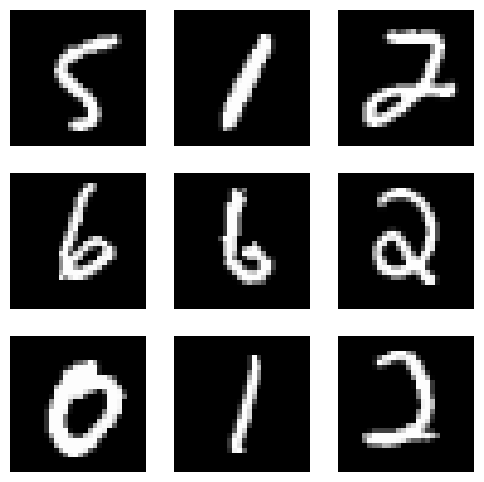

In [8]:
plot_mnist_images(x_train, num_images=9)

## 4. Build the Convolutional Neural Network (CNN)

Define the CNN model architecture:

- **Input layer:** 28x28 grayscale images

    $X \in \mathbb{R}^{28 \times 28 \times 1}$

- **Convolutional Layers:** 8 filters, 5x5 kernel, single stride, ReLU activation

    $Z \in \mathbb{R}^{24 \times 24 \times 8}$

- **Max Pooling layer:** 2x2 pooling, stride 2

    $A' \in \mathbb{R}^{12 \times 12 \times 8}$

- **Flatten:** 

    $A' \in \mathbb{R}^{12 \times 12 \times 8} \Rightarrow \mathbb{R}^{1152}$

- **Full Connected Layer:** 10 neurons

    $Z_{\text{fc}} = W_{\text{fc}} A' + b_{\text{fc}}$

    with, 
    - $W_{\text{fc}} \in \mathbb{R}^{10 \times 1152}$ is the weight matrix mapping 1152 features to 10 classes
    - $b_{\text{fc}} \in \mathbb{R}^{10}$ is the bias vector for the fully connected layer

- **Softmax Activation:**

   $\hat{y}_i = \frac{e^{Z_{\text{fc},i}}}{\sum_{j=1}^{10} e^{Z_{\text{fc},j}}}$


In [9]:
# Build the CNN model
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(filters=8, kernel_size=(5, 5), strides=1, padding='valid'),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Activation('softmax')
])

In [10]:
# Display the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 24, 24, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        11,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,738 (45.85 KB)

 Trainable params: 11,738 (45.85 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile and Train the Model
Compile the model with the Adam optimizer and categorical cross-entropy loss function, then train the model on a subset of the data to initialize the weights.


In [11]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [12]:
# Train the model on a subset on the training data
history = model.fit(x_train, y_train, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8367 - loss: 0.5585
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9596 - loss: 0.1403
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9730 - loss: 0.0927
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9805 - loss: 0.0686
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9827 - loss: 0.0586
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9852 - loss: 0.0480
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9854 - loss: 0.0459
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9877 - loss: 0.0402
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9896 - loss: 0.0344
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9898 - loss: 0.0337


## 6. Evaluate the Model
Evaluate the trained model on a validation or test set to assess its performance. The accuracy of the model is reported as a metric.

### 6.1 Plot the training history

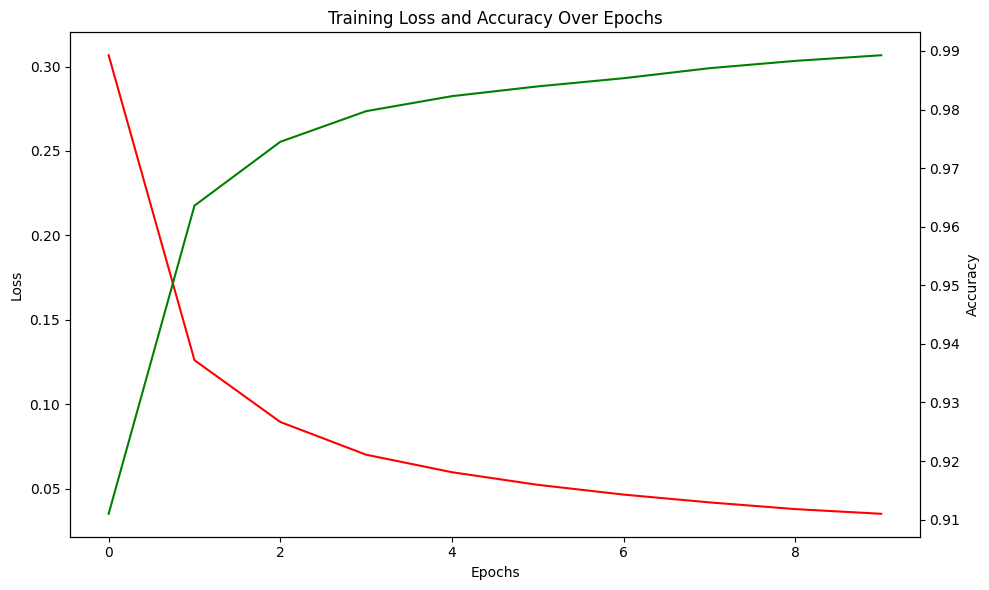

In [13]:
# Create a figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the training loss
ax1.plot(history.history['loss'], label='Training Loss', color='red')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss',)
ax1.tick_params(axis='y')

# Create a second y-axis for accuracy
ax2 = ax1.twinx()
ax2.plot(history.history['accuracy'], label='Training Accuracy', color='green')
ax2.set_ylabel('Accuracy')
ax2.tick_params(axis='y')

# Add title
plt.title('Training Loss and Accuracy Over Epochs')

# Display the plot
fig.tight_layout()
plt.show()


### 3.2 Evaluate the model on the test set

In [14]:
# Evaluate the model on the entire training set
test_loss, test_accuracy = model.evaluate(x_val, y_val, verbose=0)

print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.9832


## 7. Save the Model Weights to a Text File
Extract the weights and biases from each layer of the trained model and save them in a clean, space-separated text file format.

### 7.1 Define a class for saving model weights

In [165]:
class ModelWeightsSaver:
    @staticmethod
    def _write_conv_kernels(f, kernels, name):
        """Write conv kernels with max meaningful precision depending on dtype."""
        f.write(f"\n--- {name} ---\n")
        h, w, in_channels, out_channels = kernels.shape

        dtype = kernels.dtype
        if dtype == np.float16:
            precision = 4
        elif dtype == np.float32:
            precision = 7
        elif dtype == np.float64:
            precision = 15
        else:
            precision = 6

        fmt = f"{{: >{precision + 3}.{precision}f}}"
        
        for out_c in range(out_channels):
            for in_c in range(in_channels):
                for row in kernels[:, :, in_c, out_c]:
                    f.write(".float ")
                    formatted_vals = [fmt.format(v) for v in row]
                    f.write(", ".join(formatted_vals) + "\n")
                f.write("\n")

    @staticmethod
    def _write_array_plain(f, array, name):
        """Fallback for dense/bias arrays with dtype-dependent precision."""
        f.write(f"\n--- {name} ---\n")

        flat = array.flatten()
        length = len(flat)

        if length > 300:
            nums_per_line = 1152
        elif length == 8:
            nums_per_line = 8
        elif length == 10:
            nums_per_line = 10
        else:
            nums_per_line = 5

        dtype = array.dtype
        if dtype == np.float16:
            precision = 4
        elif dtype == np.float32:
            precision = 7
        elif dtype == np.float64:
            precision = 15
        else:
            precision = 6

        fmt = f"{{: >{precision + 3}.{precision}f}}"

        for i in range(0, length, nums_per_line):
            chunk = flat[i:i + nums_per_line]
            f.write(".float ")
            f.write(", ".join(fmt.format(v) for v in chunk) + "\n")

            if nums_per_line == 5 and (i // nums_per_line + 1) % 5 == 0:
                f.write("\n")

    @staticmethod
    def save(model, filename):
        """Save model weights to a text file."""
        with open(filename, "w") as f:
            for i, layer in enumerate(model.layers):
                weights = layer.get_weights()
                f.write(f"\n==============================\n")
                f.write(f"Layer {i+1}: {layer.name.upper()}\n")
                f.write(f"==============================\n")
                if weights:
                    w = weights[0]
                    if len(w.shape) == 4:  # conv layer
                        ModelWeightsSaver._write_conv_kernels(f, w, "Weights")
                    else:
                        ModelWeightsSaver._write_array_plain(f, w, "Weights")

                    if len(weights) > 1:
                        ModelWeightsSaver._write_array_plain(f, weights[1], "Biases")
                else:
                    f.write("(No trainable weights)\n")

### 7.2 Save the Model

In [166]:
ModelWeightsSaver.save(model, "mnist_cnn_weights.txt")
model.save(f'mnist_cnn_model.keras')

## 8. Float16 Conversion for Embedded and RISC-V Systems

Convert model weights from 32-bit floating point to 16-bit floating point format. This reduces memory usage and improves inference efficiency on embedded and RISC-V platforms while preserving most of the model’s accuracy.

In [167]:
def convert_weights_to_fp16(model):
    # Clone the model architecture with dtype='float16'
    def clone_with_fp16(layer):
        # Try to recreate layer with dtype float16 if supported
        config = layer.get_config()
        config['dtype'] = 'float16'
        try:
            new_layer = layer.__class__.from_config(config)
        except:
            # fallback to original layer if dtype arg not supported
            new_layer = layer
        return new_layer

    model_fp16 = tf.keras.models.clone_model(
        model,
        clone_function=clone_with_fp16
    )

    # Cast weights to float16
    fp16_weights = [w.astype(np.float16) for w in model.get_weights()]
    model_fp16.set_weights(fp16_weights)

    return model_fp16

In [168]:
model_fp16 = convert_weights_to_fp16(model)

for layer in model_fp16.layers:
    weights = layer.get_weights()
    print(f"{layer.name}: {[w.dtype for w in weights]}")


conv2d: [dtype('float16'), dtype('float16')]
activation: []
max_pooling2d: []
flatten: []
dense: [dtype('float16'), dtype('float16')]
activation_1: []


### 8.1 Test Memory Usage for 32-bit and 16-bit Weights

In [169]:
def get_model_mem_str(model, unit='KB'):
    # Combine all weights (trainable + non-trainable)
    all_weights = model.weights

    total_params = sum(np.prod(w.shape) for w in all_weights)

    # Get bytes per element based on dtype (e.g., float16 = 2, float32 = 4)
    if len(all_weights) > 0:
        dtype = all_weights[0].dtype
        bytes_per_param = np.dtype(dtype).itemsize
    else:
        bytes_per_param = 0

    total_bytes = total_params * bytes_per_param

    if unit.lower() == 'bytes':
        value = total_bytes
        unit_str = 'Bytes'
        return f"{total_params:,} ({value:.2f} {unit_str})"
    elif unit.lower() == 'kb':
        value = total_bytes / 1024
        unit_str = 'KB'
        return f"{total_params:,} ({value:.2f} {unit_str})"
    elif unit.lower() == 'bits':
        value = total_bytes * 8
        unit_str = 'bits'
        return f"{total_params:,} ({int(value)} {unit_str})"
    else:
        raise ValueError("Invalid unit. Choose from 'bytes', 'KB', or 'bits'.")


In [170]:
print("Model weights and biases in float32:", get_model_mem_str(model))
print("Model weights and biases in float16:", get_model_mem_str(model_fp16))

Model weights and biases in float32: 11,738 (45.85 KB)
Model weights and biases in float16: 11,738 (22.93 KB)


### 8.2 Evaluate and Compare Model Accuracies

In [171]:
test_loss_fp32, test_accuracy_fp32 = model.evaluate(x_val, y_val, verbose=0)
test_loss_fp16, test_accuracy_fp16 = model_fp16.evaluate(x_val, y_val, verbose=0)

print(f"Test accuracy (float32): {test_accuracy_fp32:.4f}")
print(f"Test accuracy (float16): {test_accuracy_fp16:.4f}")

Test accuracy (float32): 0.9832
Test accuracy (float16): 0.9832


### 8.3 Save the 16-bit Weights

In [172]:
ModelWeightsSaver.save(model_fp16, "mnist_cnn_weights_fp16.txt")
model_fp16.save(f'mnist_cnn_model_fp16.keras')